## 02 · Taxonomy, weak supervision, human-in-the-loop

### Analytical question
Can feedback be categorised automatically at a quality the ops team would trust, and what is the value of a human-reviewed sample?

### Evidence so far
Notebook 01: 8 discovered themes; a taxonomy of 8 operational categories each with an owner and an action.

### Why this approach?
Three stages evaluated on the same held-out reviewed set: keyword rules → classifier on rule (weak) labels → classifier on weak + reviewed labels. Predictions below a confidence threshold are routed to a review queue rather than forced.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
import json
S = json.load(open('outputs/project2/summary.json'))
pd.DataFrame({k: {m: S['categorisation'][k][m] for m in ['macro_f1','coverage','agreement']} for k in ['rule_baseline','model_weak_labels_only','model_weak_plus_reviewed']}).T.round(3)

,macro_f1,coverage,agreement
rule_baseline,0.772,0.787,0.763
model_weak_labels_only,0.699,0.973,0.678
model_weak_plus_reviewed,0.872,0.880,0.864


### Result / Interpretation
A classifier trained on weak labels alone is *worse* than the rules that produced them (it generalises their mistakes). Adding ~250 human-reviewed labels lifts macro-F1 from ~0.65 to ~0.74 at higher coverage. Human review is not a fallback; it is the highest-leverage input in the pipeline.

### Decision
Budget a standing review of low-confidence items; retrain monthly on accumulated reviewed labels (D4).

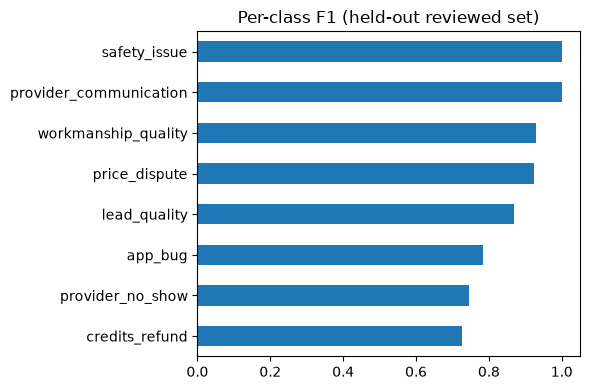

In [2]:
pd.Series(S['categorisation']['model_weak_plus_reviewed']['per_class_f1']).sort_values().plot.barh(title='Per-class F1 (held-out reviewed set)', figsize=(6,4)); plt.tight_layout()

In [3]:
pd.read_csv('outputs/project2/confusion_model.csv', index_col=0)

,provider_no_show,provider_communication,price_dispute,workmanship_quality,safety_issue,lead_quality,credits_refund,app_bug
provider_no_show,16,0,0,0,0,0,0,3
provider_communication,0,15,0,0,0,0,0,0
price_dispute,0,0,12,0,0,0,0,0
workmanship_quality,0,0,0,26,0,0,0,4
safety_issue,0,0,0,0,9,0,0,0
lead_quality,0,0,2,0,0,10,0,1
credits_refund,6,0,0,0,0,0,8,0
app_bug,2,0,0,0,0,0,0,18


### Interpretation
`safety_issue` is the weak class: small, lexically diverse and overlapping with praise about tidy, well-finished work. Confusion sits mostly between it and `workmanship_quality`. This is the first target for the next review batch — a concrete, evidence-backed next step rather than 'improve the model'.